## Step 0: Setup and Environment

**YOUR TASK:** Load the environment variables from your `.env` file containing your OpenAI API key.

**Instructions:**
1. Import `os`, `load_dotenv`, and `find_dotenv` from `dotenv`
2. Call `load_dotenv()` with `find_dotenv()` and `override=True`
3. Get the API key using `os.getenv("OPENAI_API_KEY")`
4. Print a verification message

In [1]:
# STUDENT TODO: Load environment variables and verify API key
# Step 1: Import os and dotenv functions
# Step 2: Load the .env file
# Step 3: Get OPENAI_API_KEY
# Step 4: Verify with a print statement

import os
from dotenv import load_dotenv, find_dotenv

# Load the .env file
load_dotenv(find_dotenv(), override=True)

# Verify the API key is loaded (show first 10 chars only for security)
api_key = os.getenv("OPENAI_API_KEY")
if api_key:
    print(f"✅ API Key loaded: {api_key[:10]}...")
else:
    print("❌ API Key not found! Check your .env file")


✅ API Key loaded: sk-proj-3n...


## Step 1: Install Required Packages

Install all necessary packages for the complete RAG pipeline.

In [ ]:
# STUDENT TODO: Uncomment and run to install packages
# !pip install langchain langchain-community langchain-openai langchain-text-splitters
# !pip install pypdf faiss-cpu chromadb
# !pip install InstructorEmbedding sentence-transformers
# !pip install python-dotenv

print("✅ All packages installed!")

## Part 1: Why RAG? (15 min)

Understanding the motivation and benefits of Retrieval-Augmented Generation.

### What is RAG?

**Retrieval-Augmented Generation (RAG)** is a technique that enhances LLMs by retrieving relevant information from external knowledge bases before generating responses.

**The Problem RAG Solves:**
- 🚫 **Hallucinations**: LLMs make up facts when they don't know the answer
- 📅 **Outdated Knowledge**: LLMs have a knowledge cutoff date
- 🔒 **No Private Data**: LLMs can't access your company's internal documents
- 💰 **Expensive Retraining**: Updating an LLM requires costly fine-tuning

### How RAG Works

**RAG Pipeline Flow:**
```
User Question
     ↓
Retrieve Relevant Documents (Vector Search)
     ↓
Combine Question + Retrieved Context
     ↓
Send to LLM
     ↓
Generate Grounded Answer
```

**Key Benefits:**
- ✅ **Factual Answers**: Responses based on actual documents
- ✅ **No Hallucinations**: LLM uses provided context, not imagination
- ✅ **Up-to-Date**: Add new documents without retraining
- ✅ **Transparent**: See which documents were used
- ✅ **Cost-Effective**: No expensive fine-tuning needed

### RAG Use Cases

**Where RAG Excels:**
- 📚 **Customer Support**: Answer questions from documentation
- 🏢 **Enterprise Search**: Query company knowledge bases
- ⚖️ **Legal/Compliance**: Search through regulations and contracts
- 🏥 **Healthcare**: Access medical research and patient records
- 📰 **News & Research**: Get latest information on specific topics
- 💼 **Internal Knowledge**: Company wikis, SOPs, handbooks

### RAG vs Fine-tuning

| Aspect | RAG | Fine-tuning |
|--------|-----|-------------|
| **Knowledge Update** | Real-time, just update docs | Requires retraining |
| **Cost** | Lower (retrieval + inference) | Higher (training GPUs) |
| **Hallucinations** | Reduced (grounded in docs) | Can still hallucinate |
| **Transparency** | Citations/sources provided | Black box |
| **Use Case** | Dynamic, factual knowledge | Task-specific behavior |

**When to use RAG:**
- Need up-to-date information
- Want to cite sources
- Have structured knowledge base
- Limited training budget

**When to fine-tune:**
- Need specific tone/style
- Task-specific behavior (e.g., code generation)
- Have labeled training data

### Load Text Document

Now let's load the text file using LangChain's TextLoader.

In [2]:
# STUDENT TODO: Load a text document using TextLoader
# Steps:
# 1. Import TextLoader from langchain_community.document_loaders
# 2. Create a TextLoader instance for "sample_document.txt"
# 3. Call .load() to load the document
# 4. Print the number of documents loaded and content preview

# Your code here:
# from langchain_community.document_loaders import ...
# loader = ...
# documents = ...
# print(f"📄 Number of documents loaded: {len(documents)}")
# ...

# Import the TextLoader from LangChain (v1.x style)
from langchain_community.document_loaders import TextLoader

# Load the text document
loader = TextLoader("sample_document.txt", encoding = "utf-8")
documents = loader.load()

# Print the results
print(f"Number of documents loaded: {len(documents)}")
print(f"Length of document content: {len(documents[0].page_content)} Characters")
print("\n" + "="*60)
print("Document Content Preview:")
print("="*60)
print(documents[0].page_content[:200] + "...")
print("\n" + "="*60)
print("Document Metadata:")
print("="*60)
print(documents[0].metadata)

d:\Mentoring\learwithsarvesh\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of documents loaded: 1
Length of document content: 4319 Characters

Document Content Preview:

Retrieval-Augmented Generation (RAG) is a powerful technique in artificial intelligence that combines the strengths of two distinct approaches: retrieval-based systems and generative models. This hyb...

Document Metadata:
{'source': 'sample_document.txt'}


### Load PDF Document

Let's also demonstrate loading a PDF file.

In [3]:
# STUDENT TODO: Load a PDF document using PyPDFLoader
# Steps:
# 1. Import PyPDFLoader from langchain_community.document_loaders
# 2. Create a PyPDFLoader instance for your PDF file
# 3. Call .load() to load the document
# 4. Print the number of PDF pages and content preview

# Your code here:
# from langchain_community.document_loaders import ...
# pdf_loader = ...
# pdf_documents = ...
# print(f"📄 Number of PDF pages loaded: {len(pdf_documents)}")
# ...
# Import the PyPDFLoader from LangChain (v1.x style)
from langchain_community.document_loaders import PyPDFLoader

# Load the PDF document
pdf_loader =PyPDFLoader("HDFC-Life-Group-Term-Life-Policy.pdf")
pdf_documents = pdf_loader.load()

# Print the results
print(f"📄 Number of PDF pages loaded: {len(pdf_documents)}")
print(f"📏 Length of first page content: {len(pdf_documents[0].page_content)} characters")
print("\n" + "="*60)
print("PDF Page Content:")
print("="*60)
print(pdf_documents[0].page_content)
print("\n" + "="*60)
print("PDF Page Metadata:")
print("="*60)
print(pdf_documents[0].metadata)


📄 Number of PDF pages loaded: 30
📏 Length of first page content: 430 characters

PDF Page Content:
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 0                        
 
 
 
 
 
   HDFC Life Group Term Life 
 
OF 
 
 
«OWNERNAME» 
 
 
 
 
 
  
Based on the Proposal and the declarations and 
any 
statement made or referred to therein, 
We will pay the Benefits mentioned in this Policy 
subject to the terms and conditions contained 
herein 
 
 
 
 
 
 
<< Designation of the Authorised Signatory >>

PDF Page Metadata:
{'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': '2023-08-24T19:47:11+05:30', 'title': 'Exide Life Group Term Life (UIN 114N012V03) – Terms and Conditions', 'author': 'Atul Bhatia', 'moddate': '2023-08-24T19:47:11+05:30', 'source': 'HDFC-Life-Group-Term-Life-Policy.pdf', 'total_pages': 30, 'page': 0, 'page_label': '1'}


---

## Part 2: Text Splitters & Chunking (20 min)

### Why Chunking Matters
- **Context Windows**: LLMs have token limits
- **Precision**: Smaller chunks = better semantic search
- **Cost**: Less tokens per retrieval = lower cost

### Document Loading Basics

Before we can chunk documents, we need to load them. LangChain provides various document loaders:

**TextLoader** - For .txt files
```python
from langchain_community.document_loaders import TextLoader
loader = TextLoader("file.txt")
documents = loader.load()
```

**PyPDFLoader** - For PDF files
```python
from langchain_community.document_loaders import PyPDFLoader
pdf_loader = PyPDFLoader("file.pdf")
pdf_documents = pdf_loader.load()
```

Other loaders: CSVLoader, UnstructuredMarkdownLoader, WebBaseLoader, etc.

In [4]:
# STUDENT TODO: Create a RecursiveCharacterTextSplitter
# Steps:
# 1. Import RecursiveCharacterTextSplitter from langchain_text_splitters
# 2. Create a splitter with:
#    - chunk_size=500
#    - chunk_overlap=100
# 3. Print confirmation message

# Your code here:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 100,
    length_function = len,
    is_separator_regex = False,
)

print("    Text Splitter cretd with:")
print(f"   - Chunk size: 500 characters")
print(f"   - Chunk overlap: 100 characters")
print(f"   - Overlap helps preserve context between chunks!")

    Text Splitter cretd with:
   - Chunk size: 500 characters
   - Chunk overlap: 100 characters
   - Overlap helps preserve context between chunks!


In [5]:
# STUDENT TODO: Split the PDF documents into chunks
# Steps:
# 1. Use text_splitter.split_documents() on pdf_documents
# 2. Print the total number of chunks
# 3. Print the length of the first 3 chunks

# Your code here:
chunks = text_splitter.split_documents(pdf_documents)

print("="*60)
print("DOCUMENT SPLITTING RESULTS")
print("="*60)
print(f"\n📊 Total number of chunks: {len(chunks)}")
print(f"\n📏 Length of first 3 chunks:")
for i in range(min(3, len(chunks))):
    print(f"   Chunk {i+1}: {len(chunks[i].page_content)} characters")

DOCUMENT SPLITTING RESULTS

📊 Total number of chunks: 213

📏 Length of first 3 chunks:
   Chunk 1: 430 characters
   Chunk 2: 467 characters
   Chunk 3: 452 characters


In [6]:
# STUDENT TODO: Display the first 3 chunks
# Steps:
# 1. Loop through the first 3 chunks
# 2. Print chunk number, length, and content

# Your code here:
print("\n" + "="*60)
print("CHUNK CONTENTS")
print("="*60)

for i in range(min(3, len(chunks))):
    print(f"\n{'─'*60}")
    print(f"CHUNK {i+1} ({len(chunks[i].page_content)} characters)")
    print(f"{'─'*60}")
    print(chunks[i].page_content)
    print(f"{'─'*60}")


CHUNK CONTENTS

────────────────────────────────────────────────────────────
CHUNK 1 (430 characters)
────────────────────────────────────────────────────────────
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 0                        
 
 
 
 
 
   HDFC Life Group Term Life 
 
OF 
 
 
«OWNERNAME» 
 
 
 
 
 
  
Based on the Proposal and the declarations and 
any 
statement made or referred to therein, 
We will pay the Benefits mentioned in this Policy 
subject to the terms and conditions contained 
herein 
 
 
 
 
 
 
<< Designation of the Authorised Signatory >>
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
CHUNK 2 (467 characters)
────────────────────────────────────────────────────────────
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 1                        
 
 
PART A: Covering Letter with Policy Schedule 
                                                

### Understanding Chunk Overlap

Let's demonstrate how overlap preserves context between chunks:

In [7]:
# Check if we have at least 2 chunks to demonstrate overlap
if len(chunks) >= 2:
    print("="*60)
    print("DEMONSTRATING CHUNK OVERLAP")
    print("="*60)
    
    # Get the last 100 characters of chunk 1
    chunk1_end = chunks[0].page_content[-100:]
    
    # Get the first 100 characters of chunk 2
    chunk2_start = chunks[1].page_content[:100]
    
    print("\n🔍 Last 100 characters of Chunk 1:")
    print("─"*60)
    print(f"...{chunk1_end}")
    
    print("\n🔍 First 100 characters of Chunk 2:")
    print("─"*60)
    print(f"{chunk2_start}...")
    
    # Find common text (overlap)
    print("\n" + "="*60)
    print("💡 OVERLAP ANALYSIS")
    print("="*60)
    
    # Simple overlap detection
    overlap_found = False
    for length in range(100, 0, -1):
        if chunk1_end[-length:] in chunk2_start:
            print(f"✅ Found {length} characters of overlap!")
            print(f"\nOverlapping text:")
            print("─"*60)
            print(chunk1_end[-length:])
            print("─"*60)
            print("\n📌 This overlap helps maintain context when a sentence")
            print("   or concept is split across chunks!")
            overlap_found = True
            break
    
    if not overlap_found:
        print("ℹ️ Chunks may not have direct overlap in this example")
        print("   (depends on the document content)")
else:
    print("Document is too small to demonstrate overlap")

DEMONSTRATING CHUNK OVERLAP

🔍 Last 100 characters of Chunk 1:
────────────────────────────────────────────────────────────
...he terms and conditions contained 
herein 
 
 
 
 
 
 
<< Designation of the Authorised Signatory >>

🔍 First 100 characters of Chunk 2:
────────────────────────────────────────────────────────────
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 1                        
 
...

💡 OVERLAP ANALYSIS
ℹ️ Chunks may not have direct overlap in this example
   (depends on the document content)


In [8]:
loader = TextLoader("sample_document.txt", encoding = "utf-8")
documents = loader.load()

In [9]:
overlap_demo_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 300,
    chunk_overlap = 100,
    length_function = len,
    is_separator_regex= False
)

text_chunks = overlap_demo_splitter.split_documents(documents)

print(f"Total Chunks: {len(text_chunks)}\n")

Total Chunks: 24



In [10]:
if len(text_chunks) >= 2:
    chunk1_end = text_chunks[0].page_content[-100:]
    chunk2_start = text_chunks[1].page_content[:100]
    
    print("Chunk 1 (last 100 chars):")
    print(chunk1_end)
    print("\nChunk 2 (first 100 chars):")
    print(chunk2_start)
    
    # Find overlap
    for length in range(100, 0, -1):
        if chunk1_end[-length:] in chunk2_start:
            print(f"\n✅ Overlap: {length} characters")
            print(f"\n{chunk1_end[-length:]}")
            break
    else:
        print("\n❌ No overlap found (sentence boundaries respected)")

Chunk 1 (last 100 chars):
This hybrid methodology has revolutionized how we build intelligent systems that can access external

Chunk 2 (first 100 chars):
hybrid methodology has revolutionized how we build intelligent systems that can access external know

✅ Overlap: 95 characters

hybrid methodology has revolutionized how we build intelligent systems that can access external


### Comparing Different Chunk Sizes

Let's experiment with different chunk sizes to understand the trade-offs:

In [11]:
# STUDENT TODO: Create two different text splitters
# Steps:
# 1. Create small_chunk_splitter with chunk_size=300, overlap=50
# 2. Create large_chunk_splitter with chunk_size=1000, overlap=100
# 3. Split documents with both splitters
# 4. Compare the number of chunks created

# Your code here:
# small_chunk_splitter = ...
# large_chunk_splitter = ...
# small_chunks = ...
# large_chunks = ...
# print(f"Small chunks: {len(small_chunks)}, Large chunks: {len(large_chunks)}")

small_chunk_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 300,
    chunk_overlap = 50,
    length_function = len,
)


large_chunk_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 100,
    length_function = len,
)

small_chunks = small_chunk_splitter.split_documents(documents)
large_chunks = large_chunk_splitter.split_documents(documents)

print("="*70)
print("CHUNK SIZE COMPARISON")
print("="*70)
print(f"\n📦 SMALL CHUNKS (size=300):")
print(f"   Total chunks created: {len(small_chunks)}")
print(f"\n📦 LARGE CHUNKS (size=1000):")
print(f"   Total chunks created: {len(large_chunks)}")
print(f"\n📊 Difference: {len(small_chunks) - len(large_chunks)} more chunks with smaller size")

CHUNK SIZE COMPARISON

📦 SMALL CHUNKS (size=300):
   Total chunks created: 24

📦 LARGE CHUNKS (size=1000):
   Total chunks created: 5

📊 Difference: 19 more chunks with smaller size


In [12]:
# Visualize the chunk size distribution
print("="*70)
print("CHUNK SIZE DISTRIBUTION")
print("="*70)

print("\n📊 Small Chunks (300 char limit):")
for i in range(min(len(small_chunks), 5)):
    print(f"   Chunk {i+1}: {len(small_chunks[i].page_content):>3} characters")

print("\n📊 Large Chunks (1000 char limit):")
for i in range(min(len(large_chunks), 5)):
    print(f"   Chunk {i+1}: {len(large_chunks[i].page_content):>4} characters")

# Calculate statistics
if len(small_chunks) > 0:
    avg_small = sum(len(c.page_content) for c in small_chunks) / len(small_chunks)
    print(f"\n📈 Average small chunk size: {avg_small:.0f} characters")

if len(large_chunks) > 0:
    avg_large = sum(len(c.page_content) for c in large_chunks) / len(large_chunks)
    print(f"📈 Average large chunk size: {avg_large:.0f} characters")

CHUNK SIZE DISTRIBUTION

📊 Small Chunks (300 char limit):
   Chunk 1: 291 characters
   Chunk 2: 104 characters
   Chunk 3: 292 characters
   Chunk 4: 184 characters
   Chunk 5: 181 characters

📊 Large Chunks (1000 char limit):
   Chunk 1:  969 characters
   Chunk 2:  964 characters
   Chunk 3:  921 characters
   Chunk 4:  942 characters
   Chunk 5:  540 characters

📈 Average small chunk size: 187 characters
📈 Average large chunk size: 867 characters


### Trade-offs Analysis

**Small Chunks (300 characters):**

✅ **Advantages:**
- 🎯 More precise retrieval - specific information is easier to find
- 💰 Lower embedding costs (fewer tokens per chunk)
- ⚡ Faster similarity search
- 🔍 Better for specific fact retrieval

❌ **Disadvantages:**
- 📉 May lose broader context
- 🧩 Related information might be split apart
- 🔄 More chunks to process and manage
- ⚠️ Risk of incomplete information in a single chunk

---

**Large Chunks (1000 characters):**

✅ **Advantages:**
- 📚 Preserves more context in each chunk
- 🔗 Related information stays together
- 📉 Fewer chunks to manage
- 💡 Better for understanding complex topics

❌ **Disadvantages:**
- 💸 Higher embedding costs
- 🐌 May retrieve irrelevant information along with relevant parts
- 🎯 Less precise retrieval
- 📊 Larger context window usage in LLM

---

**💡 Best Practice:**
- Start with **500-1000 characters** for general use
- Use **smaller chunks** (200-500) for Q&A systems with specific facts
- Use **larger chunks** (1000-2000) for documents needing more context
- Always **experiment and measure** what works best for your use case!

---

## Part 3: Embeddings (OpenAI + Instructor + Local) (20 min)

### What are Embeddings?

Embeddings convert text into numerical vectors that capture semantic meaning. Similar texts have similar vectors.

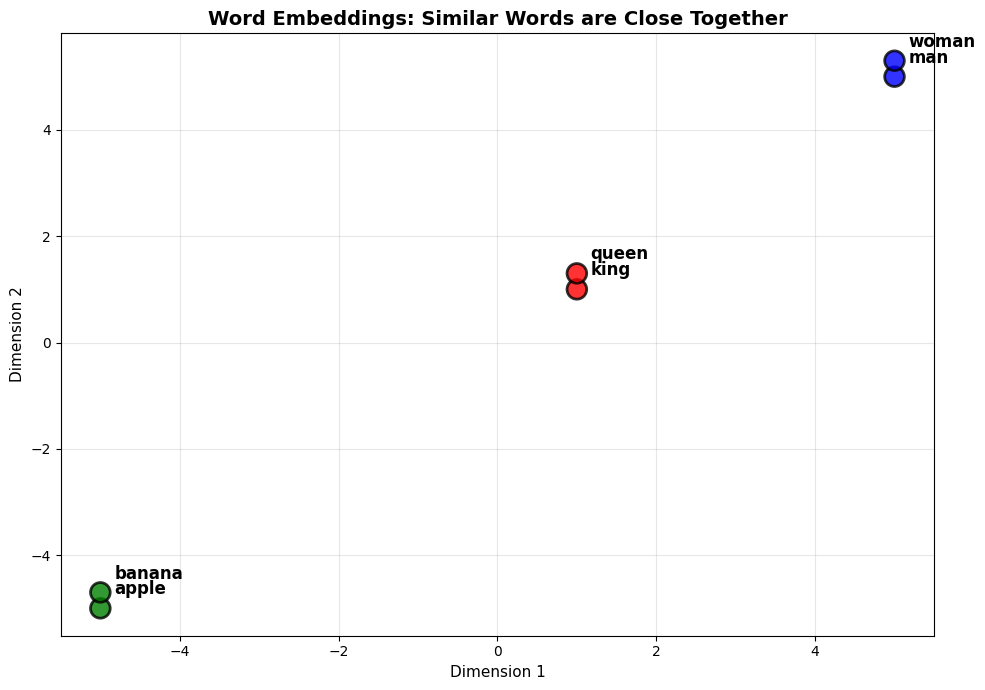

✅ WORD EMBEDDINGS CONCEPT:

📍 RED cluster (Royalty):
   - 'king' at position [1, 1]
   - 'queen' at position [1, 1.1] ← Very CLOSE to king
   - Distance between king & queen: 0.1 (SIMILAR words)

📍 BLUE cluster (People):
   - 'man' at position [5, 5]
   - 'woman' at position [5, 5.1] ← Very CLOSE to man
   - Distance between man & woman: 0.1 (SIMILAR words)

📍 GREEN cluster (Fruits):
   - 'apple' at position [-5, -5]
   - 'banana' at position [-5, -4.9] ← Very CLOSE to apple
   - Distance between apple & banana: 0.1 (SIMILAR words)

💡 KEY INSIGHT:
   Similar words = Small distance between vectors
   Different categories = Far apart in the plot
   This is how embeddings capture SEMANTIC MEANING!


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Create simple embeddings where similar words have similar vectors
vectors = np.array([
    [1, 1],        # "king"
    [1, 1.3],      # "queen" (very close to king)
    [5, 5],        # "man"
    [5, 5.3],      # "woman" (very close to man)
    [-5, -5],      # "apple"
    [-5, -4.7]     # "banana" (very close to apple)
])

words = ["king", "queen", "man", "woman", "apple", "banana"]

# Plot without t-SNE (since our vectors are already in 2D)
plt.figure(figsize=(10, 7))
colors = {'king': 'red', 'queen': 'red', 'man': 'blue', 'woman': 'blue', 'apple': 'green', 'banana': 'green'}
color_list = [colors[word] for word in words]

plt.scatter(vectors[:, 0], vectors[:, 1], s=200, alpha=0.8, c=color_list, edgecolors='black', linewidth=2)

for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors[i, 0], vectors[i, 1]), 
                xytext=(10, 10), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title("Word Embeddings: Similar Words are Close Together", fontsize=14, fontweight='bold')
plt.xlabel("Dimension 1", fontsize=11)
plt.ylabel("Dimension 2", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ WORD EMBEDDINGS CONCEPT:")
print("\n📍 RED cluster (Royalty):")
print("   - 'king' at position [1, 1]")
print("   - 'queen' at position [1, 1.1] ← Very CLOSE to king")
print("   - Distance between king & queen: 0.1 (SIMILAR words)")

print("\n📍 BLUE cluster (People):")
print("   - 'man' at position [5, 5]")
print("   - 'woman' at position [5, 5.1] ← Very CLOSE to man")
print("   - Distance between man & woman: 0.1 (SIMILAR words)")

print("\n📍 GREEN cluster (Fruits):")
print("   - 'apple' at position [-5, -5]")
print("   - 'banana' at position [-5, -4.9] ← Very CLOSE to apple")
print("   - Distance between apple & banana: 0.1 (SIMILAR words)")

print("\n💡 KEY INSIGHT:")
print("   Similar words = Small distance between vectors")
print("   Different categories = Far apart in the plot")
print("   This is how embeddings capture SEMANTIC MEANING!")

In [14]:
# STUDENT TODO: Initialize OpenAI Embeddings
# Steps:
# 1. Import OpenAIEmbeddings from langchain_openai
# 2. Create embeddings_model with model="text-embedding-3-small"
# 3. Print confirmation message

# Your code here:
# from langchain_openai import ...
# embeddings_model = ...
# print("✅ OpenAI Embeddings model initialized")ArithmeticError

from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model = "text-embedding-3-small")


print("✅ OpenAI Embeddings model initialized")
print(f"   Model: text-embedding-3-small")

✅ OpenAI Embeddings model initialized
   Model: text-embedding-3-small


In [15]:
# Create an embedding for a simple sentence
sample_text = "Hello how are you?"

# Generate embedding
embedding_vector = embedding_model.embed_query(sample_text)

# Get dimensions
vector_dimensions = len(embedding_vector)
token_count = len(sample_text.split())  # Approximate token count (1 word ≈ 1.3 tokens)
estimated_tokens = int(token_count * 1.3)

print("="*70)
print("EMBEDDING A SIMPLE TEXT")
print("="*70)

print(f"\n📝 Input Text: '{sample_text}'")
print(f"   Word Count: {token_count} words")
print(f"   Estimated Tokens: {estimated_tokens} tokens")

print(f"\n📊 Vector Dimensions: {vector_dimensions}")
print(f"   This means the sentence is represented as a vector with {vector_dimensions} numbers")
print(f"   Each number captures semantic meaning of the text")

print(f"\n💰 COST CALCULATION:")
print(f"   Model: text-embedding-3-small")
print(f"   Price: $0.02 per 1 million input tokens")
print(f"   Tokens used: {estimated_tokens}")
print(f"   Cost for this sentence: ${(estimated_tokens / 1_000_000) * 0.02:.10f}")
print(f"   (extremely cheap - this sentence costs ~1/50,000,000 of a dollar!)")

print(f"\n🔍 First 10 dimensions of the embedding vector:")
print(f"   {embedding_vector[:10]}")

print(f"\n💡 KEY INSIGHTS:")
print(f"   - The entire sentence is compressed into {vector_dimensions} numbers")
print(f"   - These numbers capture the semantic meaning")
print(f"   - Similar sentences will have similar vectors")
print(f"   - Cost is EXTREMELY low for embeddings (measured in fractions of a cent)")


EMBEDDING A SIMPLE TEXT

📝 Input Text: 'Hello how are you?'
   Word Count: 4 words
   Estimated Tokens: 5 tokens

📊 Vector Dimensions: 1536
   This means the sentence is represented as a vector with 1536 numbers
   Each number captures semantic meaning of the text

💰 COST CALCULATION:
   Model: text-embedding-3-small
   Price: $0.02 per 1 million input tokens
   Tokens used: 5
   Cost for this sentence: $0.0000001000
   (extremely cheap - this sentence costs ~1/50,000,000 of a dollar!)

🔍 First 10 dimensions of the embedding vector:
   [0.026506535708904266, -0.05321657657623291, -0.014779556542634964, 0.05703229829668999, -0.018302738666534424, -0.018302738666534424, 0.015517261810600758, 0.018913252279162407, -0.031238028779625893, -0.06400234997272491]

💡 KEY INSIGHTS:
   - The entire sentence is compressed into 1536 numbers
   - These numbers capture the semantic meaning
   - Similar sentences will have similar vectors
   - Cost is EXTREMELY low for embeddings (measured in fraction

In [16]:
# STUDENT TODO: Create embeddings for sample text chunks
# Steps:
# 1. Create a list of 3 sample text chunks
# 2. Use embeddings_model.embed_documents() to create embeddings
# 3. Print number of embeddings and dimension size

# Your code here:
# sample_chunks = [
#     "...",
#     "...",
#     "..."
# ]
# chunk_embeddings = ...
# print(f"📊 Number of chunks embedded: {len(chunk_embeddings)}")

# Create sample text chunks to convert into embeddings
sample_chunks = [
    "RAG combines retrieval and generation for better AI responses.",
    "Embeddings convert text into numerical vectors.",
    "LangChain makes it easy to build RAG applications."
]

# Convert text chunks into embeddings (numerical vectors)
chunk_embeddings = embedding_model.embed_documents(sample_chunks)

print("="*60)
print("EMBEDDINGS CREATED")
print("="*60)
print(f"\n📊 Number of chunks embedded: {len(chunk_embeddings)}")
print(f"📏 Length of a single embedding vector: {len(chunk_embeddings[0])} dimensions")
print(f"\n💡 Each dimension is a number that captures semantic meaning")

EMBEDDINGS CREATED

📊 Number of chunks embedded: 3
📏 Length of a single embedding vector: 1536 dimensions

💡 Each dimension is a number that captures semantic meaning


### Comparing Similar Sentences

Let's see how embeddings capture similarity between sentences.

In [17]:
# STUDENT TODO: Create embeddings for sentences and calculate similarity
# Steps:
# 1. Import numpy
# 2. Create 3 sentences (2 similar, 1 different)
# 3. Use embeddings_model.embed_query() for each sentence
# 4. Create a function to calculate cosine similarity
# 5. Compare similarity scores

# Your code here:
# import numpy as np
# sentence1 = "..."
# sentence2 = "..."
# sentence3 = "..."
# emb1 = ...
# emb2 = ...
# emb3 = ...
# def cosine_similarity(vec1, vec2):
#     return ...
# ...

import numpy as np

# Two similar sentences about AI
sentence1 = "Artificial intelligence helps solve complex problems."
sentence2 = "AI assists in solving difficult challenges."

sentence3 = "I enjoy eating pizza for dinner."

# Create embeddings for these sentences:
emb1 = embedding_model.embed_query(sentence1)
emb2 = embedding_model.embed_query(sentence2)
emb3 = embedding_model.embed_query(sentence3)

print("="*60)
print("SENTENCE EMBEDDINGS CREATED")
print("="*60)
print(f"\n✅ Created embeddings for 3 sentences")
print(f"📏 Each embedding has {len(emb1)} dimensions")


def cosine_similarity(vec1, vec2):
    """Calculate similarity between two vectors (0 to 1)"""
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Compare the similar sentences
similarity_1_2 = cosine_similarity(emb1, emb2)

# Compare sentence 1 with the different sentence
similarity_1_3 = cosine_similarity(emb1, emb3)

print("\n" + "="*60)
print("SIMILARITY COMPARISON")
print("="*60)
print(f"\n📝 Sentence 1: '{sentence1}'")
print(f"📝 Sentence 2: '{sentence2}'")
print(f"🔗 Similarity: {similarity_1_2:.4f} (SIMILAR MEANING)")

print(f"\n📝 Sentence 1: '{sentence1}'")
print(f"📝 Sentence 3: '{sentence3}'")
print(f"❌ Similarity: {similarity_1_3:.4f} (DIFFERENT MEANING)")

print("\n" + "="*60)
print("💡 Higher similarity score = more related content")
print("💡 This is how RAG finds relevant information!")
print("="*60)

SENTENCE EMBEDDINGS CREATED

✅ Created embeddings for 3 sentences
📏 Each embedding has 1536 dimensions

SIMILARITY COMPARISON

📝 Sentence 1: 'Artificial intelligence helps solve complex problems.'
📝 Sentence 2: 'AI assists in solving difficult challenges.'
🔗 Similarity: 0.7275 (SIMILAR MEANING)

📝 Sentence 1: 'Artificial intelligence helps solve complex problems.'
📝 Sentence 3: 'I enjoy eating pizza for dinner.'
❌ Similarity: 0.0589 (DIFFERENT MEANING)

💡 Higher similarity score = more related content
💡 This is how RAG finds relevant information!


### Embeddings Comparison

| Embedding Model | Dimension | Cost | Speed | Best For |
|----------------|-----------|------|-------|----------|
| **OpenAI text-embedding-3-small** | 1536 | $0.02/1M tokens | Fast | Production, high quality |
| **Instructor-XL** | 768 | Free | Medium | Instruction-following tasks |
| **all-MiniLM-L6-v2** | 384 | Free | Very Fast | Local, privacy-focused |

**💡 Recommendation:**
- Start with **OpenAI** for simplicity
- Use **Instructor** for better instruction understanding
- Use **Sentence Transformers** for local/offline deployment

---

## Part 4: Vector Databases (FAISS, Chroma) (30 min)

### What are Vector Databases?

Vector databases store embeddings and enable fast similarity search. They're the backbone of RAG systems.

In [20]:
# STUDENT TODO: Create a FAISS vector store
# Steps:
# 1. Import FAISS from langchain_community.vectorstores
# 2. Use FAISS.from_documents() with your chunks and embeddings_model
# 3. Print confirmation message

# Your code here:
# from langchain_community.vectorstores import ...
# vectorstore = ...
# print("✅ FAISS vector store created successfully")

from langchain_community.vectorstores import FAISS

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 100
)

chunks = text_splitter.split_documents(documents)

print(f"Total Chunks: {len(chunks)}")

vectorstore = FAISS.from_documents(
    documents = chunks,
    embedding= embedding_model
)




Total Chunks: 12


In [22]:
# STUDENT TODO: Perform a similarity search
# Steps:
# 1. Define a search query
# 2. Use vectorstore.similarity_search() with k=3
# 3. Print the query and number of results
# 4. Display the results

# Your code here:
# query = "..."
# retrieved_chunks = ...
# print(f"🔍 Query: '{query}'")
# print(f"📊 Retrieved {len(retrieved_chunks)} chunks")
# for i, chunk in enumerate(retrieved_chunks, 1):
#     print(f"CHUNK {i}: {chunk.page_content[:100]}...")

query = "What is retrieval-augmented generation?"

retrived_chunks = vectorstore.similarity_search(query, k = 3)

print(f"Retrived {len(retrived_chunks)} most relevent chunks")

for i, chunks in enumerate(retrived_chunks, 1):
    print(f"Content:\n {chunks.page_content}\n")
    print(f"Metadata: {chunks.metadata}")

Retrived 3 most relevent chunks
Content:
 Retrieval-Augmented Generation (RAG) is a powerful technique in artificial intelligence that combines the strengths of two distinct approaches: retrieval-based systems and generative models. This hybrid methodology has revolutionized how we build intelligent systems that can access external knowledge while generating contextually relevant responses.

Metadata: {'source': 'sample_document.txt'}
Content:
 The future of AI will likely involve increasingly sophisticated RAG systems that can effectively combine retrieval with generation to provide more accurate, transparent, and trustworthy AI systems.

Metadata: {'source': 'sample_document.txt'}
Content:
 3. Context Integration: The retrieved documents are formatted and provided as context to the language model along with the original query.

4. Generation: The language model uses both the query and the retrieved context to generate a response that is grounded in actual information from the knowled

### Similarity Search with Scores 

In [23]:
results_with_score = vectorstore.similarity_search_with_score(query, k = 3)

for i, (chunk, score) in enumerate(results_with_score, 1):
    print(f"Rank {i} - Distance Score: {score:.4f}")
    print(f"{chunk.page_content[:150]}...")

Rank 1 - Distance Score: 0.4610
Retrieval-Augmented Generation (RAG) is a powerful technique in artificial intelligence that combines the strengths of two distinct approaches: retrie...
Rank 2 - Distance Score: 0.8544
The future of AI will likely involve increasingly sophisticated RAG systems that can effectively combine retrieval with generation to provide more acc...
Rank 3 - Distance Score: 1.0098
3. Context Integration: The retrieved documents are formatted and provided as context to the language model along with the original query.

4. Generat...


In [24]:
# STUDENT TODO: Create a Chroma vector store with persistence
# Steps:
# 1. Import Chroma from langchain_community.vectorstores
# 2. Define persist_directory = "./chroma_db"
# 3. Add metadata to chunks (chunk_index, source)
# 4. Use Chroma.from_documents() with persist_directory
# 5. Print confirmation

# Your code here:
# from langchain_community.vectorstores import ...
# persist_directory = "..."
# for i, chunk in enumerate(chunks):
#     chunk.metadata["chunk_index"] = i
# chroma_vectorstore = ...
# print("✅ Chroma vector store created with persistence")

from langchain_community.vectorstores import Chroma

persist_directory = "./chroma_db"

print(f"Persistence Directory: {persist_directory}")


Persistence Directory: ./chroma_db


In [34]:
for i, chunk in enumerate(retrived_chunks, 1):
    print(f"Content:\n {chunk.page_content}\n")
    print(f"Metadata: {chunk.metadata}")

Content:
 Retrieval-Augmented Generation (RAG) is a powerful technique in artificial intelligence that combines the strengths of two distinct approaches: retrieval-based systems and generative models. This hybrid methodology has revolutionized how we build intelligent systems that can access external knowledge while generating contextually relevant responses.

Metadata: {'source': 'sample_document.txt'}
Content:
 The future of AI will likely involve increasingly sophisticated RAG systems that can effectively combine retrieval with generation to provide more accurate, transparent, and trustworthy AI systems.

Metadata: {'source': 'sample_document.txt'}
Content:
 3. Context Integration: The retrieved documents are formatted and provided as context to the language model along with the original query.

4. Generation: The language model uses both the query and the retrieved context to generate a response that is grounded in actual information from the knowledge base.

Benefits of RAG:

Meta

In [38]:
# Re-create chunks list (in case it was overwritten by a loop variable)
chunks = text_splitter.split_documents(documents)

# Prepare chunks with metadata before creating Chroma vector store
for i, chunk in enumerate(chunks):
    chunk.metadata["chunk_index"] = i
    chunk.metadata["source"] = "sample_document.txt"

chroma_vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory=persist_directory
)

print("="*60)
print("CHROMA VECTOR STORE CREATED")
print("="*60)
print(f"✅ Vector store created with persistence")
print(f"📊 Stored {len(chunks)} chunks with embeddings")
print(f"💾 Data saved to disk at: {persist_directory}")
print(f"💡 This data persists even after restarting the notebook!")

CHROMA VECTOR STORE CREATED
✅ Vector store created with persistence
📊 Stored 12 chunks with embeddings
💾 Data saved to disk at: ./chroma_db
💡 This data persists even after restarting the notebook!


In [39]:
# Perform a search to verify it works
test_query = "What is RAG?"
search_results = chroma_vectorstore.similarity_search(test_query, k=2)

print("\n" + "="*60)
print("INITIAL SEARCH TEST")
print("="*60)
print(f"🔍 Query: '{test_query}'")
print(f"📊 Found {len(search_results)} results\n")

for i, result in enumerate(search_results, 1):
    print(f"Result {i}:")
    print(f"  Content: {result.page_content[:100]}...")
    print(f"  Metadata: {result.metadata}\n")


INITIAL SEARCH TEST
🔍 Query: 'What is RAG?'
📊 Found 2 results

Result 1:
  Content: The core concept of RAG is elegant yet powerful. Instead of relying solely on the knowledge encoded ...
  Metadata: {'chunk_index': 1, 'source': 'sample_document.txt'}

Result 2:
  Content: The core concept of RAG is elegant yet powerful. Instead of relying solely on the knowledge encoded ...
  Metadata: {'chunk_index': 1, 'source': 'sample_document.txt'}



In [40]:
# Delete the current vector store object to simulate a restart
del chroma_vectorstore

print("="*60)
print("SIMULATING RESTART")
print("="*60)
print("🗑️  Deleted vector store from memory")
print("💾 But data still exists on disk!")

SIMULATING RESTART
🗑️  Deleted vector store from memory
💾 But data still exists on disk!


In [41]:
# Reload the vector store from disk
# No need to recreate embeddings - they're already stored!
reloaded_vectorstore = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding_model
)

print("\n" + "="*60)
print("VECTOR STORE RELOADED FROM DISK")
print("="*60)
print(f"✅ Successfully loaded from: {persist_directory}")
print(f"⚡ No need to recreate embeddings - they were saved!")
print(f"💡 This saves time and API costs!")


VECTOR STORE RELOADED FROM DISK
✅ Successfully loaded from: ./chroma_db
⚡ No need to recreate embeddings - they were saved!
💡 This saves time and API costs!


C:\Users\sarve\AppData\Local\Temp\ipykernel_15468\3179159276.py:3: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  reloaded_vectorstore = Chroma(


In [42]:
# Perform the same search on the reloaded vector store
reloaded_results = reloaded_vectorstore.similarity_search(test_query, k=2)

print("\n" + "="*60)
print("SEARCH ON RELOADED VECTOR STORE")
print("="*60)
print(f"🔍 Query: '{test_query}'")
print(f"📊 Found {len(reloaded_results)} results\n")

for i, result in enumerate(reloaded_results, 1):
    print(f"Result {i}:")
    print(f"  Content: {result.page_content[:100]}...")
    print(f"  Metadata: {result.metadata}\n")

print("="*60)
print("✅ PERSISTENCE VERIFIED!")
print("="*60)
print("The vector store works perfectly after reloading!")
print("Same results, no re-embedding needed!")


SEARCH ON RELOADED VECTOR STORE
🔍 Query: 'What is RAG?'
📊 Found 2 results

Result 1:
  Content: The core concept of RAG is elegant yet powerful. Instead of relying solely on the knowledge encoded ...
  Metadata: {'source': 'sample_document.txt', 'chunk_index': 1}

Result 2:
  Content: The core concept of RAG is elegant yet powerful. Instead of relying solely on the knowledge encoded ...
  Metadata: {'chunk_index': 1, 'source': 'sample_document.txt'}

✅ PERSISTENCE VERIFIED!
The vector store works perfectly after reloading!
Same results, no re-embedding needed!


### Benefits of Persistence

**Why persistence matters:**

✅ **Saves Time**: No need to recreate embeddings every time  
✅ **Saves Money**: Reduces API calls to embedding services  
✅ **Production Ready**: Vector stores can be shared across sessions  
✅ **Scalability**: Store large document collections efficiently  

**Key differences between FAISS and Chroma:**

| Feature | FAISS | Chroma |
|---------|-------|--------|
| Persistence | Manual (save/load) | Built-in |
| Metadata | Limited | Rich metadata support |
| Updates | Recreate index | Add/update/delete easily |
| Best for | Speed, in-memory | Persistence, production |

In [ ]:
# STUDENT TODO: Test retrieval on reloaded vector store
# Steps:
# 1. Delete chroma_vectorstore from memory (del chroma_vectorstore)
# 2. Reload using Chroma(persist_directory=..., embedding_function=...)
# 3. Perform a search to verify persistence
# 4. Print comparison showing same results

# Your code here:
# del chroma_vectorstore
# reloaded_vectorstore = ...
# reloaded_results = ...
# print("✅ PERSISTENCE VERIFIED!")

---

## Part 5: Retrieval Chain (25 min)

### Understanding Retrievers

Retrievers provide a simple interface for retrieving relevant documents based on queries.

In [49]:
# STUDENT TODO: Create a retriever from the vector store
# Steps:
# 1. Use reloaded_vectorstore.as_retriever()
# 2. Set search_kwargs={"k": 3} for top 3 results
# 3. Print confirmation message

# Your code here:
# retriever = ...
# print("✅ Retriever created from vector store")

retriever = reloaded_vectorstore.as_retriever(
    search_kwargs = {"k": 3}
)

user_query = "How does RAG reduce hallucinations in AI systems?"

retrieved_docs = retriever.invoke(user_query)

for i, doc in enumerate(retrieved_docs, 1):
    print(f"{doc.page_content}\n")
    print(f" Source: {doc.metadata.get('source', 'N/A')}")
    print(f" Chunk Index: {doc.metadata.get('chunk_index', 'N/A')}")

Benefits of RAG:

Reduced Hallucinations: By providing factual context, RAG significantly reduces the likelihood of the model generating false or made-up information. The model is constrained to base its responses on the provided context.

Up-to-Date Information: Unlike traditional language models that are frozen at training time, RAG systems can be updated simply by adding new documents to the knowledge base. There is no need for expensive retraining.

 Source: sample_document.txt
 Chunk Index: 4
Retrieval-Augmented Generation (RAG) is a powerful technique in AI.

RAG combines the benefits of retrieval-based systems and generative models.
It allows us to provide context to large language models by retrieving relevant 
information from a knowledge base.

This approach helps reduce hallucinations and provides more accurate,
fact-based responses. RAG is commonly used in chatbots, question-answering 
systems, and document analysis applications.

 Source: sample_document.txt
 Chunk Index: 

In [50]:
# Example: Testing retrieval with different queries
test_queries = [
    "What is RAG?",
    "How does retrieval work?",
    "What are the benefits of using LangChain?"
]

print("="*60)
print("TESTING RETRIEVER WITH MULTIPLE QUERIES")
print("="*60)

for query in test_queries:
    results = retriever.invoke(query)
    print(f"\n🔍 Query: '{query}'")
    print(f"✅ Retrieved {len(results)} chunks")
    # Show just the first 80 characters of the first result
    if results:
        print(f"📄 First result preview: {results[0].page_content[:80]}...")
    print("-" * 60)

TESTING RETRIEVER WITH MULTIPLE QUERIES

🔍 Query: 'What is RAG?'
✅ Retrieved 3 chunks
📄 First result preview: The core concept of RAG is elegant yet powerful. Instead of relying solely on th...
------------------------------------------------------------

🔍 Query: 'How does retrieval work?'
✅ Retrieved 3 chunks
📄 First result preview: How RAG Works:

1. Query Processing: When a user submits a query, it is first pr...
------------------------------------------------------------

🔍 Query: 'What are the benefits of using LangChain?'
✅ Retrieved 3 chunks
📄 First result preview: Implementing RAG Systems:

Modern RAG implementations typically use vector datab...
------------------------------------------------------------


### Advanced Retrieval Strategies

Beyond simple similarity search, there are several advanced retrieval strategies:

**1. MMR (Maximal Marginal Relevance)**
- Balances relevance with diversity
- Avoids returning duplicate/similar chunks
- Usage: `as_retriever(search_type="mmr")`

**2. Similarity Score Threshold**
- Only return chunks above a certain similarity score
- Filters out low-quality matches
- Usage: `as_retriever(search_type="similarity_score_threshold", search_kwargs={"score_threshold": 0.8})`

**3. Contextual Compression**
- Compresses retrieved documents to extract only relevant parts
- Reduces token usage
- Requires a compressor model

**4. Ensemble Retrieval**
- Combines multiple retrieval methods (e.g., BM25 + vector search)
- Often provides better results than single method

In [ ]:
# STUDENT TODO: Use the retriever to fetch relevant documents
# Steps:
# 1. Define a user query
# 2. Use retriever.invoke(user_query)
# 3. Print the query and number of retrieved documents
# 4. Display the retrieved documents

# Your code here:
# user_query = "..."
# retrieved_docs = ...
# print(f"🔍 User Query: '{user_query}'")
# print(f"📊 Retrieved {len(retrieved_docs)} relevant chunks")
# for i, doc in enumerate(retrieved_docs, 1):
#     print(f"CHUNK {i}: {doc.page_content}...")

---

## Part 6: Building Your First RAG Pipeline (30 min)

### Complete End-to-End RAG System

Now let's build a complete RAG system that generates answers using retrieved context.

In [51]:
# STUDENT TODO: Import RAG components (LangChain 1.0.x LCEL approach)
# Steps:
# 1. Import ChatOpenAI from langchain_openai
# 2. Import ChatPromptTemplate from langchain_core.prompts
# 3. Import StrOutputParser from langchain_core.output_parsers
# 4. Import RunnablePassthrough from langchain_core.runnables
# 5. Print confirmation message

# Your code here:
# from langchain_openai import ...
# from langchain_core.prompts import ...
# from langchain_core.output_parsers import ...
# from langchain_core.runnables import ...
# print("✅ Imported LangChain components")
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough


In [52]:
# STUDENT TODO: Initialize the LLM
# Steps:
# 1. Create ChatOpenAI with model="gpt-3.5-turbo"
# 2. Set temperature=0 for factual responses
# 3. Print confirmation

# Your code here:
# llm = ...
# print("✅ Step 1: LLM Initialized")

llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0  # Lower temperature for more factual responses
)

In [54]:
# STUDENT TODO: Create a prompt template for RAG
# Steps:
# 1. Create system_prompt that tells LLM to use retrieved context
# 2. Use ChatPromptTemplate.from_messages() with system and human messages
# 3. Include {context} and {input} placeholders
# 4. Print confirmation

# Your code here:
# system_prompt = (
#     "You are an assistant for question-answering tasks. "
#     "Use the following pieces of retrieved context to answer the question. "
#     "If you don't know the answer, say that you don't know. "
#     "Use three sentences maximum and keep the answer concise."
#     "\n\n"
#     "{context}"
# )
# prompt = ...
# print("✅ Step 2: Prompt Template Created")

system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know. Use three sentences maximum and keep the "
    "answer concise."
    "\n\n"
    "{context}"
)

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
])

In [55]:
# STUDENT TODO: Create the complete RAG chain using LCEL
# Steps:
# 1. Create a format_docs() function that joins documents
# 2. Build rag_chain using pipe operator (|):
#    - Retriever with format_docs
#    - Prompt
#    - LLM
#    - StrOutputParser
# 3. Print confirmation

# Your code here:
# def format_docs(docs):
#     return "\n\n".join(doc.page_content for doc in docs)
# rag_chain = (
#     {"context": ..., "input": ...}
#     | prompt
#     | llm
#     | StrOutputParser()
# )
# print("🎉 RAG PIPELINE READY!")

def format_docs(docs):
    """Format retrieved documents into a string"""
    return "\n\n".join(doc.page_content for doc in docs)

## Build the LCEL chain:
rag_chain = (
    {"context": retriever | format_docs, "input": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [56]:
# STUDENT TODO: Test the RAG pipeline with a question
# Steps:
# 1. Define a question
# 2. Invoke the RAG chain with rag_chain.invoke(question)
# 3. Print the question and answer

# Your code here:
# question = "..."
# answer = ...
# print(f"❓ Question: {question}")
# print(f"💡 Answer: {answer}")

question = "What is Retrieval-Augumented Generation and how does it help reduce hallucinations?"

answer = rag_chain.invoke(question)


In [57]:
print(f"{question}")
print(f"\n{answer}")

What is Retrieval-Augumented Generation and how does it help reduce hallucinations?

Retrieval-Augmented Generation (RAG) is a powerful AI technique that combines retrieval-based systems and generative models to provide context to large language models by retrieving relevant information from a knowledge base. RAG helps reduce hallucinations by constraining the model to base its responses on the factual context retrieved from the knowledge base, thus minimizing the generation of false or made-up information.


In [59]:
# STUDENT TODO: Show the retrieved context used for the answer
# Steps:
# 1. Use retriever.invoke(question) to get documents
# 2. Print the retrieved context chunks
# 3. Display metadata for each chunk

# Your code here:
# retrieved_docs = ...
# print("RETRIEVED CONTEXT USED FOR ANSWER")
# for i, doc in enumerate(retrieved_docs, 1):
#     print(f"Context {i}: {doc.page_content}")
#     print(f"Source: {doc.metadata.get('source', 'N/A')}")

question = "What is Retrieval-Augumented Generation and how does it help reduce hallucinations?"
retrieved_docs = retriever.invoke(question)

for i, doc in enumerate(retrieved_docs, 1):
    print(f"{doc.page_content}\n")
    print(f"Source: {doc.metadata.get('source', 'NA')}")

Retrieval-Augmented Generation (RAG) is a powerful technique in AI.

RAG combines the benefits of retrieval-based systems and generative models.
It allows us to provide context to large language models by retrieving relevant 
information from a knowledge base.

This approach helps reduce hallucinations and provides more accurate,
fact-based responses. RAG is commonly used in chatbots, question-answering 
systems, and document analysis applications.

Source: sample_document.txt
Retrieval-Augmented Generation (RAG) is a powerful technique in artificial intelligence that combines the strengths of two distinct approaches: retrieval-based systems and generative models. This hybrid methodology has revolutionized how we build intelligent systems that can access external knowledge while generating contextually relevant responses.

Source: sample_document.txt
Benefits of RAG:

Reduced Hallucinations: By providing factual context, RAG significantly reduces the likelihood of the model generating 

In [60]:
# Try another question
question2 = "What are common use cases for RAG?"

# Invoke the RAG chain
answer2 = rag_chain.invoke(question2)

print("\n" + "="*60)
print("ANOTHER RAG QUERY")
print("="*60)
print(f"\n❓ Question:")
print(f"{question2}\n")
print(f"{'─'*60}")
print(f"\n💡 Answer:")
print(f"{answer2}\n")
print("="*60)

# Show retrieved context for this question too
retrieved_docs2 = retriever.invoke(question2)
print(f"\n✅ Retrieved {len(retrieved_docs2)} context chunks")


ANOTHER RAG QUERY

❓ Question:
What are common use cases for RAG?

────────────────────────────────────────────────────────────

💡 Answer:
Common use cases for RAG (Retrieval-Augmented Generation) systems include powering intelligent support chatbots for customer support that can provide consistent and accurate responses by leveraging company documentation and knowledge bases. Organizations can also build domain-specific RAG systems by curating relevant documents and knowledge bases to specialize in their specific domain, enhancing the accuracy and relevance of generated responses.


✅ Retrieved 3 context chunks


---

## 🎓 Summary

You've built a complete RAG system! You now know how to:

✅ Load documents from various sources  
✅ Split documents into optimal chunks  
✅ Create embeddings for semantic search  
✅ Store embeddings in vector databases (FAISS, Chroma)  
✅ Retrieve relevant context for queries  
✅ Build complete RAG pipelines with LLMs  

**You're ready to build production RAG applications!** 🚀

**Next challenges:**
- Build a RAG system for your own documents
- Experiment with different chunk sizes and overlap
- Try different embedding models
- Explore advanced retrieval strategies (MMR, hybrid search)
- Add memory and conversation history
- Deploy your RAG application to production